<a href="https://colab.research.google.com/github/Jos-lab02/ExamenBimestrlB/blob/main/ExamenBimestralB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KPI 1: Tasa de Rotación de Personal (Attrition Rate)

Este indicador muestra qué porcentaje de trabajadores dejó la empresa en relación con el total de empleados registrados en la base de datos. Para obtener este valor se utilizó la siguiente fórmula:

### Fórmula

$$
Attrition\ Rate=
\frac{\text{Número de empleados que abandonaron la empresa}}
{\text{Número total de empleados}}
\times 100
$$

### Justificación

La variable **Attrition** registra si un trabajador continúa en la empresa o si ya no forma parte de ella. Al comparar la cantidad de empleados que salieron con el total de registros, se obtiene una medida directa de la rotación de personal.

---

# KPI 2: Ingreso Promedio Mensual por Departamento

Este KPI permite observar cuánto ganan, en promedio, los empleados de cada departamento.

### Fórmula

$$
Ingreso\ Promedio=
\frac{\text{Suma de los ingresos mensuales del departamento}}
{\text{Número de empleados del departamento}}
$$

### Justificación

Para este cálculo se tomó la variable **MonthlyIncome** y se obtuvo su promedio dentro de cada departamento. De esta manera es posible comparar los niveles salariales entre las distintas áreas de la organización.

---

# KPI 3: Índice de Balance Vida-Trabajo Promedio por Cargo

Este indicador refleja la valoración promedio que tienen los empleados sobre su equilibrio entre trabajo y vida personal según el cargo que desempeñan.

### Fórmula

$$
WorkLifeBalance\ Promedio=
\frac{\text{Suma de las calificaciones de WorkLifeBalance}}
{\text{Número de empleados del cargo}}
$$

### Justificación

La variable **WorkLifeBalance** está expresada en una escala de 1 a 4. Al calcular el promedio para cada cargo se puede observar cómo perciben los trabajadores su balance entre responsabilidades laborales y vida personal.

---

# KPI 4: Brecha de Estancamiento Laboral por Departamento

Este indicador analiza cuánto tiempo permanecen los empleados en su puesto actual en comparación con el tiempo transcurrido desde su última promoción, para cada departamento se uso la siguiente formula

### Fórmula

$$
Brecha\ Promedio_{Departamento}=
\frac{\text{Suma de las diferencias entre los años en el cargo actual y los años desde la última promoción}}
{\text{Número de empleados del departamento}}
$$

### Justificación

Para cada departamento se calcula el promedio de la diferencia entre los años que los empleados llevan en su puesto actual y los años transcurridos desde su última promoción. Un valor más alto puede indicar que los trabajadores permanecen más tiempo en el mismo cargo sin oportunidades de crecimiento o ascenso



Número de registros: 1470

KPI 1: Tasa de Rotación de Personal (Attrition Rate)
Empleados que salieron: 237
Total empleados: 1470
Tasa de rotación: 16.12%



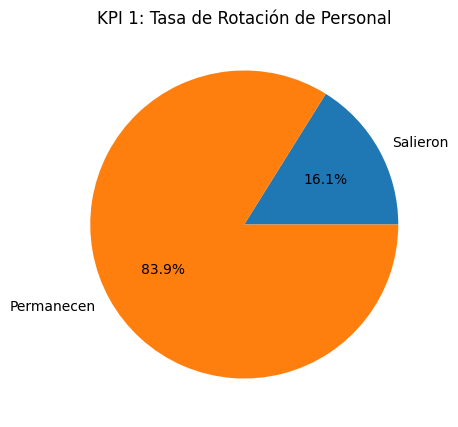

KPI 2: Ingreso Promedio Mensual por Departamento

Departamento: Human Resources
Ingreso promedio mensual: $6,654.51

Departamento: Research & Development
Ingreso promedio mensual: $6,281.25

Departamento: Sales
Ingreso promedio mensual: $6,959.17


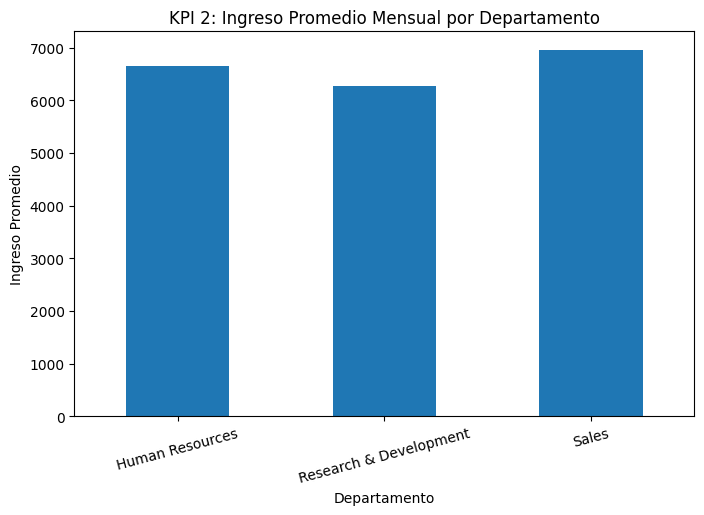


KPI 3: Índice de Balance Vida-Trabajo (Work-Life Balance Promedio) por Cargo

Cargo: Healthcare Representative
Balance vida-trabajo promedio: 2.7/4

Cargo: Human Resources
Balance vida-trabajo promedio: 2.92/4

Cargo: Laboratory Technician
Balance vida-trabajo promedio: 2.72/4

Cargo: Manager
Balance vida-trabajo promedio: 2.77/4

Cargo: Manufacturing Director
Balance vida-trabajo promedio: 2.77/4

Cargo: Research Director
Balance vida-trabajo promedio: 2.86/4

Cargo: Research Scientist
Balance vida-trabajo promedio: 2.68/4

Cargo: Sales Executive
Balance vida-trabajo promedio: 2.8/4

Cargo: Sales Representative
Balance vida-trabajo promedio: 2.89/4


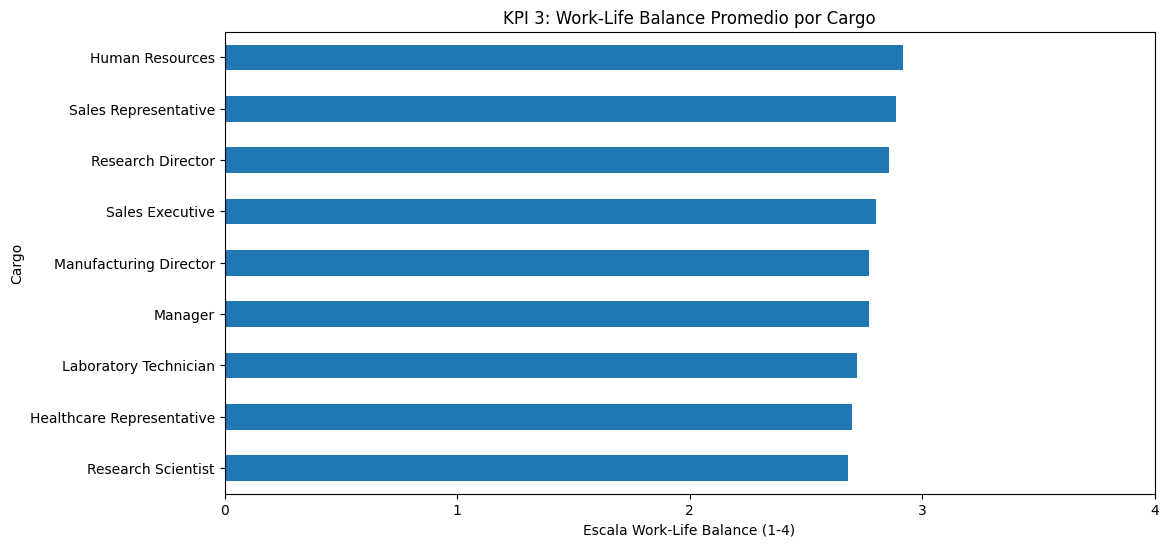


KPI 4: Brecha de Estancamiento Laboral por Departamento

Human Resources: 1.76 años
Research & Development: 2.02 años
Sales: 2.13 años


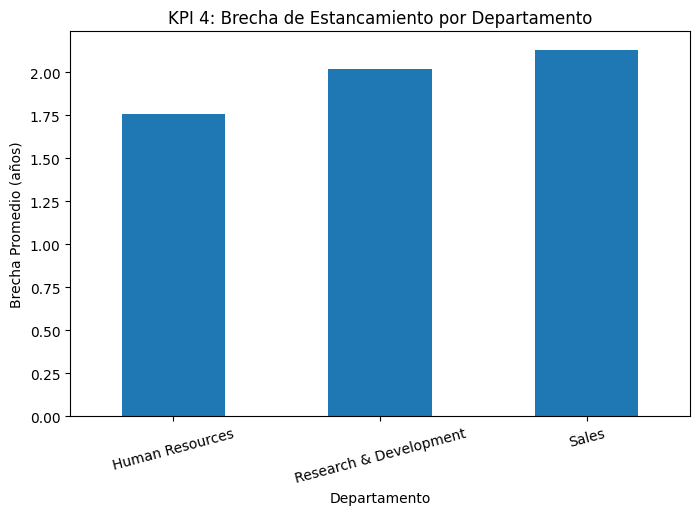

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

ruta = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(ruta)

print("Número de registros:", len(df))
print()


# KPI 1: TASA DE ROTACIÓN DE PERSONAL (ATTRITION RATE)


total_empleados = len(df)

empleados_salieron = df[df["Attrition"] == "Yes"].shape[0]

attrition_rate = (empleados_salieron / total_empleados) * 100

print("KPI 1: Tasa de Rotación de Personal (Attrition Rate)")
print(f"Empleados que salieron: {empleados_salieron}")
print(f"Total empleados: {total_empleados}")
print(f"Tasa de rotación: {attrition_rate:.2f}%")
print()

plt.figure(figsize=(5, 5))
plt.pie(
    [empleados_salieron, total_empleados - empleados_salieron],
    labels=["Salieron", "Permanecen"],
    autopct="%1.1f%%"
)
plt.title("KPI 1: Tasa de Rotación de Personal")
plt.show()



# KPI 2: INGRESO PROMEDIO MENSUAL POR DEPARTAMENTO

ingreso_promedio_departamento = (
    df.groupby("Department")["MonthlyIncome"]
    .mean()
    .round(2)
)

print("KPI 2: Ingreso Promedio Mensual por Departamento")

for departamento, ingreso in ingreso_promedio_departamento.items():
    print(f"\nDepartamento: {departamento}")
    print(f"Ingreso promedio mensual: ${ingreso:,.2f}")

plt.figure(figsize=(8, 5))
ingreso_promedio_departamento.plot(kind="bar")
plt.title("KPI 2: Ingreso Promedio Mensual por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Ingreso Promedio")
plt.xticks(rotation=15)
plt.show()

# KPI 3: ÍNDICE DE BALANCE VIDA-TRABAJO POR CARGO

wlb_promedio_cargo = (
    df.groupby("JobRole")["WorkLifeBalance"]
    .mean()
    .round(2)
)

print("\nKPI 3: Índice de Balance Vida-Trabajo (Work-Life Balance Promedio) por Cargo")

for cargo, promedio in wlb_promedio_cargo.items():
    print(f"\nCargo: {cargo}")
    print(f"Balance vida-trabajo promedio: {promedio}/4")

plt.figure(figsize=(12, 6))
wlb_promedio_cargo.sort_values().plot(kind="barh")

plt.xlim(0, 4)
plt.xticks([0, 1, 2, 3, 4])

plt.title("KPI 3: Work-Life Balance Promedio por Cargo")
plt.xlabel("Escala Work-Life Balance (1-4)")
plt.ylabel("Cargo")
plt.show()



# KPI 4: BRECHA DE ESTANCAMIENTO LABORAL


df["BrechaEstancamiento"] = (
    df["YearsInCurrentRole"]
    - df["YearsSinceLastPromotion"]
)

brecha_departamento = (
    df.groupby("Department")["BrechaEstancamiento"]
    .mean()
    .round(2)
)

print("\nKPI 4: Brecha de Estancamiento Laboral por Departamento\n")

for departamento, brecha in brecha_departamento.items():
    print(f"{departamento}: {brecha} años")

plt.figure(figsize=(8, 5))
brecha_departamento.plot(kind="bar")

plt.title("KPI 4: Brecha de Estancamiento por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Brecha Promedio (años)")

plt.xticks(rotation=15)

plt.show()

##KPI1 :Tasa de Rotación de Personal (Attrition Rate)
En nuestro primer kpi podemos observar que el 16.1 % es el porcentaje de gente que abandono la empresa es decir que 1 de cada 6 personas estan abandonado su trabajo , por lo cual la empresa deberia analizar las razones por las cuales estan abandoanado su trabajo y tomar medidas para retener al empleado .
##KPI 2: Ingreso Promedio Mensual por Departamento
Tenemos los siguientes
Departamento: Human Resources
Ingreso promedio mensual: $6,654.51

Departamento: Research & Development
Ingreso promedio mensual: $6,281.25

Departamento: Sales
Ingreso promedio mensual: $6,959.17

Con estos datos podemos observar que el area de Sales es el que mas ingresos obtuvo mientras que el que menor ingresos tuvo fue el de Research & Development, esto tambien puede pasar por la responsabilidad que cargan cada departamento. Este indicador permite comparar las diferencias salariales entre las áreas de la organización y apoyar decisiones relacionadas con compensaciones.

##KPI 3: Índice de Balance Vida-Trabajo (Work-Life Balance Promedio) por Cargo
Cargo: Healthcare Representative: 2.7/4

Cargo: Human Resources: 2.92/4

Cargo: Laboratory Technician: 2.72/4

Cargo: Manager: 2.77/4

Cargo: Manufacturing Director: 2.77/4

Cargo: Research Director: 2.86/4

Cargo: Research Scientist: 2.68/4

Cargo: Sales Executive: 2.8/4

Cargo: Sales Representative: 2.89/4

Con lo que podemos obervar aqui la relacion vida - trabajo de los empleados esta por encima de la media , sin embargo el cargo de Research Scientist presenta una disconformidad de 2.68 siendo el cargo mas disconforme , se deberia evaluar posibles acciones para mejorar la relacion vida trabajo empezando por Research Scientist
##KPI 4: Brecha de Estancamiento Laboral (Puesto Actual vs. Última Promoción)
Brecha promedio por departamento

Human Resources: 1.76 años

Research & Development: 2.02 años

Sales: 2.13 años

Podemos evidenciar que el departamento de Sales es el que mas tiempo pasa sin tener una promocion mientras que el de Human Resources es el que obtiene una promocion en menor tiempo , con esto en mente deberiamos evaluar el por que no hay mucha promocion del departamento de Sales y identificar que se podria hacer


